# Machine Trading — Chapter 1 재현 실험

Ernest P. Chan의 *Machine Trading* 1장 전체를 학습용으로 정리하고, 공식
동반 자료가 있는 Box 1.1·1.2와 수식으로 제시된 Box 1.3을 실행한다.

> **범위:** 데이터·플랫폼·브로커 설명은 2016년 책의 역사적 맥락과 재사용할
> 원칙을 구분한다. 포트폴리오 계산은 정적 수치 실험이며 시간 순서가 있는
> 매매 성과 **백테스트는 아니다**.

확인할 질문은 다섯 가지다.

1. 연구와 실거래가 같은 전략 로직을 써야 하는 이유는 무엇인가?
2. 데이터와 성과지표에서 어떤 편향과 tail risk를 확인해야 하는가?
3. 기간을 잘게 나눌수록 `평균 로그수익률 ≈ 평균 순수익률 - 분산/2`가
   정확해지는가?
4. 공식 ETF 데이터에서 롱온리 효율적 투자선과 tangency 포트폴리오가
   책의 결과와 일치하는가?
5. Box 1.3의 `C⁻¹M` 해와 표본 분할은 최적 비중의 어떤 위험을 드러내는가?

## Chapter coverage / 구현 범위와 재현 상태

| 장의 주제 | 재현 상태 | 노트북 증거 |
|---|---|---|
| 알고리즘 트레이딩 흐름 | 개념 설명 | 연구→백테스트/실거래 시스템 도표 |
| 과거 시장 데이터 | 역사적 맥락 | 조정·상장폐지·경매가·선물 롤 체크리스트 |
| 실시간 데이터·플랫폼·브로커 | 역사적 맥락 | 지연·API·체결 상태·운영 리스크 설명 |
| 성과지표 | 실행 수식 예제+개념 | CAGR, Sharpe, MDD/duration, Calmar/MAR, scalar Kelly |
| Box 1.1 | 근사 재현·책 비교 | PCG64 시뮬레이션과 MATLAB 표본 표 |
| Box 1.2 | 수치 재현·책 비교 | 공식 ETF, 효율적 투자선, 비중 허용오차 |
| Box 1.3 | 수식 실행 진단 | 정규화 `C⁻¹M`과 롱온리 해 비교 |
| 추정 위험·risk parity | 실행 진단+개념 | 전·후반 표본 비중과 gross exposure |
| 연습문제·주석 | 범위 밖 | 원문/한국어 장 문서에 보존 |

코드가 없는 주제를 조용히 빼지 않고 개념 설명 또는 역사적 맥락으로 표시했다.
연습문제 풀이를 본 실험에 억지로 포함하지 않는다.

## 1. 하나의 전략 코어: 연구에서 주문까지

책의 Figure 1.1에서 가장 오래 남는 설계 원칙은 백테스트와 실거래가 같은
모델을 써야 한다는 것이다. 데이터 어댑터와 체결 어댑터는 달라도 신호,
포지션 상태 전이, 위험 제한은 공유해야 한다. 그래야 연구 코드와 실거래 코드의
미세한 차이 때문에 생기는 배포 오류를 줄일 수 있다.

아래 도표에서 historical data는 모의 체결·성과지표로, live data는 broker
API 주문으로 이어진다. 체결, 거부, 부분 체결과 현재 포지션은 다시 공유 상태로
돌아와야 한다.

## 2. 데이터·플랫폼·브로커 체크리스트

### 과거·실시간 데이터

- 주식/ETF는 분할·배당 조정뿐 아니라 상장폐지 종목과 당시 지수 구성종목이
  있어야 survivorship bias를 줄일 수 있다.
- 일별 시가·종가는 합성 체결가보다 주 거래소 경매가나 BBO 중간값이 실행
  가능성을 더 잘 반영할 수 있다.
- 연속선물은 롤 규칙 자체가 결과를 바꾸며 미래 롤 정보를 쓰면 look-ahead
  bias가 된다.
- 비유동 옵션은 마지막 체결가보다 bid/ask와 보조 정보가 중요하다.
- 실시간 데이터는 가격뿐 아니라 타임스탬프, 지연, 누락·중복을 검증해야 한다.

책이 열거한 CSI, Quandl, CRSP, Bloomberg 및 당시 플랫폼은 **2016년의 역사적
맥락**이다. 이 노트북은 현재 공급자 추천으로 갱신하지 않고, 공급자가 바뀌어도
유효한 데이터 품질 질문만 사용한다.

### 플랫폼과 브로커

연구 생산성과 운영 안정성은 다르다. 실거래에서는 주문 거부, 부분 체결,
재접속, 중복 주문, 마진, 계좌 보호 범위까지 다뤄야 한다. 전략의 높은 Sharpe가
이 운영 리스크를 상쇄하지는 않는다.

## 3. 성과지표: 평균뿐 아니라 tail risk

초기 자산 $V_0$, 마지막 자산 $V_T$, 연수 $Y$일 때

$$\mathrm{CAGR}=\left(\frac{V_T}{V_0}\right)^{1/Y}-1.$$

일 1%를 252일 복리화한 CAGR과 단순 연환산 252%는 전혀 다르다. 책의
레버리지 1 비교 원칙을 지키려면 일별 P&L을 전일 gross market value로
나눈 수익률을 써야 한다.

일별 초과수익률 $R_t-r_f$의 연환산 Sharpe는

$$SR=\sqrt{252}\frac{\overline{R-r_f}}{\sigma(R-r_f)}$$

로 쓸 수 있다. 최대 낙폭은 누적 자산 $V_t$와 이전 고점 $H_t$에서

$$DD_t=\frac{V_t}{H_t}-1,\qquad MDD=\min_t DD_t$$

로 구하며, drawdown duration은 고점을 회복하지 못한 기간이다. 책에서 Calmar는
CAGR/최근 36개월 MDD, MAR은 inception 이후 CAGR/inception 이후 MDD다. 긴
백테스트일수록 MDD가 커져 MAR가 표본 길이에 민감하다는 것이 책이 Calmar를
선호한 이유다.

스칼라 Kelly 최적 레버리지는

$$f^*=\frac{\operatorname{E}[R-R_f]}{\operatorname{Var}(R-R_f)}$$

이지만 fat tail과 추정오차를 반영하지 않는다. 20% 급락에 5배 노출이면 비용
전 자산이 초기 1.0에서 0.0이 되므로 leverage cap, stress test, margin 규칙이 필요하다.
변동성은 Gaussian한 흔들림을 요약할 뿐 tail risk와 유동성 위험을 모두
보여주지 않으므로 Sharpe 하나로 전략을 평가하면 안 된다.

이 장의 ETF 최적화는 시간 순서가 있는 백테스트가 아니므로 APR·MDD를 계산해
성과처럼 꾸미지 않는다. 대신 제약 충족, 책 수치, 표본 민감도를 검증한다.

## 4. 재현 환경과 실행 방식

환경은 프로젝트의 `pyproject.toml`과 `uv.lock`으로 고정한다. 원시 데이터가
없을 때만 공식 ZIP을 내려받고, 이후에는 파일 SHA-256을 검증한다. 아래 셀은
미리 만들어 둔 그림을 읽지 않는다. 모든 도표는 현재 실행에서 계산해 PNG
바이트로 셀 출력에 내장된다.

In [1]:
from io import BytesIO
from pathlib import Path
import sys

from IPython.display import Image, display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def find_project_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("pyproject.toml이 있는 프로젝트 루트를 찾지 못했습니다")

PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "chapter_1_the_basics_of_algorithmic_trading/src"
sys.path.insert(0, str(SRC_DIR))

from run_chapter1_analysis import (
    BOOK_MINIMUM_VARIANCE_WEIGHTS,
    BOOK_NET_LOG_RESULTS,
    BOOK_TANGENCY_WEIGHTS,
    CHAPTER_COVERAGE,
    DATA_PATH,
    PYPROJECT_PATH,
    UV_LOCK_PATH,
    VERIFICATION_CLASSES,
    calculate_efficient_frontier,
    calculate_net_returns,
    calculate_performance_metric_examples,
    calculate_portfolio_theory_diagnostics,
    chapter_manifest,
    create_data_diagnostics_figure,
    create_efficient_frontier_figure,
    create_net_log_figure,
    create_portfolio_theory_figure,
    create_trading_system_figure,
    download_official_assets,
    environment_versions,
    excluded_universe_diagnostics,
    load_etf_data,
    sha256_file,
    simulate_net_vs_log_returns,
    solve_global_long_only_minimum_variance,
    summarize_net_log_seed_distribution,
    validate_offline_assets,
    verify_results,
    verification_summary,
)

if not DATA_PATH.exists():
    download_official_assets()
validate_offline_assets()

def show_figure(fig):
    # 현재 실행에서 만든 그림을 노트북 출력에 직접 내장한다.
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=140, bbox_inches="tight")
    plt.close(fig)
    display(Image(data=buffer.getvalue()))

print(f"project: {PROJECT_ROOT}")
print("official assets: checksum verified")

project: /media/restful3/data/workspace/ml4t/source/Chan E. Machine Trading - Deploying Computer Algorithms to Conquer the Markets 2016
official assets: checksum verified


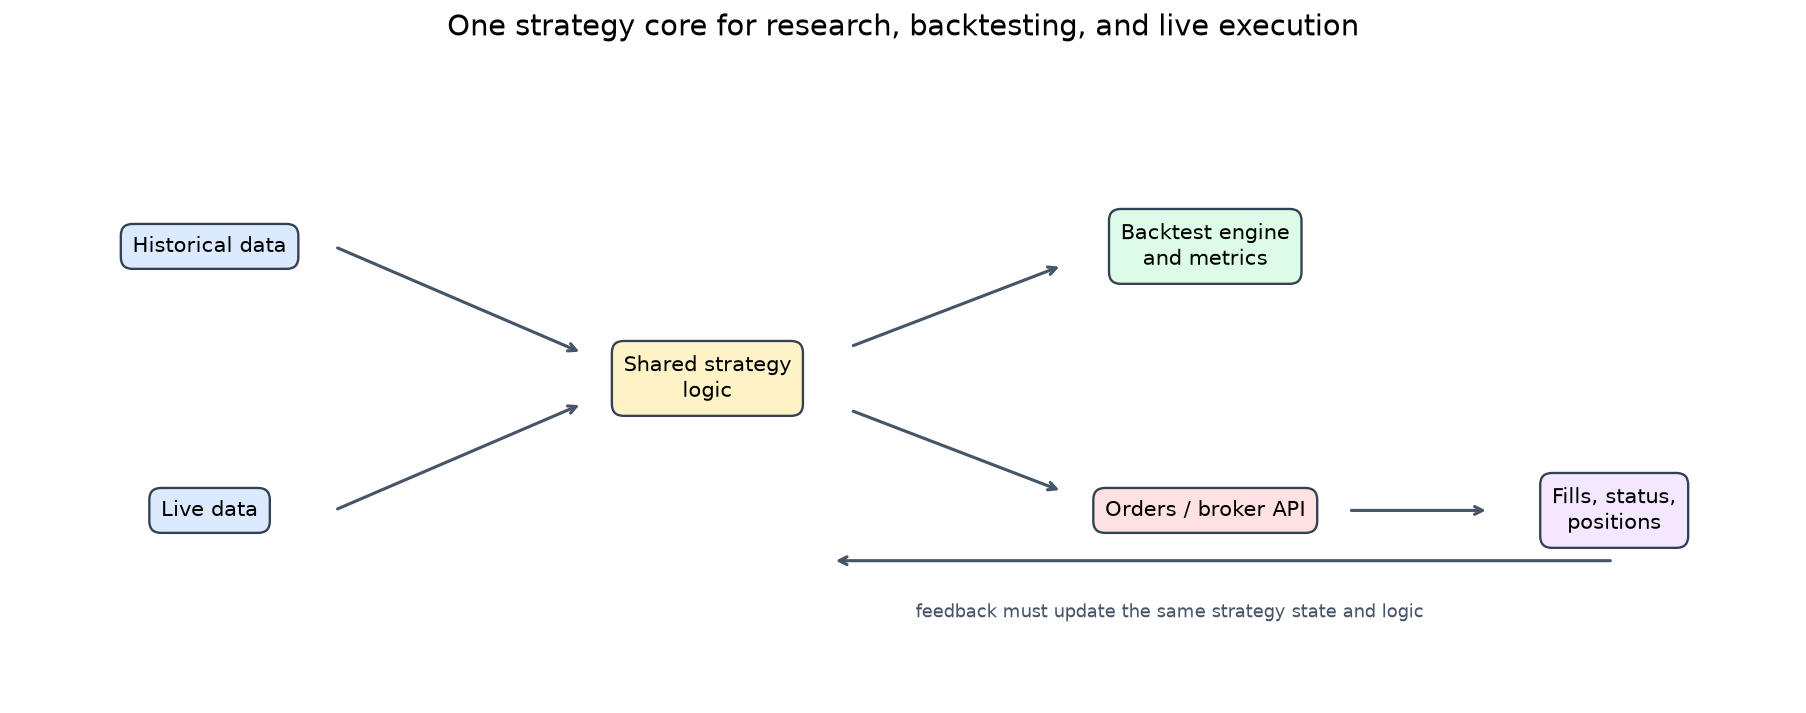

In [2]:
show_figure(create_trading_system_figure())

In [3]:
performance_example = pd.Series(
    calculate_performance_metric_examples(), name="computed value"
).to_frame()
display(performance_example)
assert performance_example.loc["cagr", "computed value"] > 11
assert performance_example.loc["remaining_wealth_after_shock", "computed value"] == 0
print("CAGR 복리 예제와 5배 tail-shock 경고 계산 통과")

,computed value
daily_return,0.010000
periods,252.000000
cagr,11.274002
simple_annualized_return,2.520000
black_monday_return,-0.200000
illustrative_leverage,5.000000
remaining_wealth_after_shock,0.000000


CAGR 복리 예제와 5배 tail-shock 경고 계산 통과


## 5. 공식 출처와 환경 provenance

공식 배포 URL, 원본 ZIP 해시, 실제 입력 MAT 해시, 잠금 파일 해시를 함께
남긴다. 같은 파일과 같은 환경을 썼는지 나중에 확인할 수 있는 최소 조건이다.

In [4]:
manifest = chapter_manifest()
data_member = next(
    member for member in manifest["members"] if member["kind"] == "research_data"
)
provenance = pd.DataFrame(
    {
        "value": {
            "source_page": manifest["source_page"],
            "archive_url": manifest["url"],
            "archive_sha256": manifest["sha256"],
            "input_member": data_member["archive_path"],
            "input_sha256": sha256_file(DATA_PATH),
            "pyproject_sha256": sha256_file(PYPROJECT_PATH),
            "uv_lock_sha256": sha256_file(UV_LOCK_PATH),
        }
    }
)
display(provenance)
display(pd.Series(environment_versions(), name="version").to_frame())

,value
source_page,https://epchan.com/book3
archive_url,https://epchan.com/img/book3/Chap1%20Basics.zip
archive_sha256,b868d52328a85df8e31aad900a6c3e5669fc226f39fbb0...
input_member,Chap1 Basics/inputDataOHLCDaily_ETF_20150417.mat
input_sha256,3d24e65d340774ad7088ee7019582fb6dd945f78de08d9...
pyproject_sha256,aa9e1978fac90e37df584eb8fcebdf34186b824dfab530...
uv_lock_sha256,d3b494323b4b7b207e1f32e4f86e1c42e24d90afc8b86e...


,version
python,3.12.3
numpy,2.5.1
pandas,3.0.3
scipy,1.18.0
matplotlib,3.11.1
nbformat,5.10.4
nbclient,0.11.0


## 6. 데이터 구조와 기본 진단

가격 $P_t$에서 일별 순수익률은 다음과 같다.

$$R_t = \frac{P_t}{P_{t-1}} - 1$$

책의 의도대로 EWZ와 FXI를 제외하고 EWC, EWG, EWJ, EWQ, EWU, EWY를 쓴다.
공식 `ef.m`은 심볼 배열을 먼저 줄인 뒤 종가 배열을 필터링하는 순서 문제가
있다. 하지만 공식 심볼 순서에서 EWZ·FXI가 마지막 두 열이어서 원본도 우연히
같은 6개 열을 선택한다. 여기서는 원래 8개 심볼에서 마스크를 한 번 계산한다.
EWZ와 FXI의 결측 수를 따로 공개해 데이터 가용성 제외와 사후 선택을 구분한다.

In [5]:
etf_data = load_etf_data(DATA_PATH)
prices = pd.DataFrame(etf_data.close, index=etf_data.dates, columns=etf_data.symbols)
returns = pd.DataFrame(
    calculate_net_returns(etf_data.close),
    index=etf_data.dates[1:],
    columns=etf_data.symbols,
)

data_diagnostics = pd.Series(
    {
        "start": prices.index.min().date(),
        "end": prices.index.max().date(),
        "rows": len(prices),
        "assets": prices.shape[1],
        "missing_values": int(prices.isna().sum().sum()),
        "nonpositive_values": int((prices <= 0).sum().sum()),
        "minimum_price": float(prices.min().min()),
        "maximum_price": float(prices.max().max()),
    },
    name="value",
)
display(data_diagnostics.to_frame())
display(pd.DataFrame(excluded_universe_diagnostics()).T)
display(prices.head())
display(prices.describe().T[["min", "mean", "std", "max"]])

,value
start,2005-05-12
end,2015-04-17
rows,2500
assets,6
missing_values,0
nonpositive_values,0
minimum_price,626.0
maximum_price,6861.0


,column,missing_values
EWZ,6,2253
FXI,7,0


,EWC,EWG,EWJ,EWQ,EWU,EWY
2005-05-12,1412.0,1388.0,894.0,1788.0,1232.0,2778.0
2005-05-13,1386.0,1379.0,886.0,1789.0,1226.0,2789.0
2005-05-16,1391.0,1395.0,887.0,1797.0,1219.0,2823.0
2005-05-17,1404.0,1391.0,884.0,1786.0,1225.0,2826.0
2005-05-18,1419.0,1411.0,890.0,1809.0,1239.0,2882.0


,min,mean,std,max
EWC,1223.0,2446.1504,444.170319,3249.0
EWG,1110.0,2221.3452,487.763192,3171.0
EWJ,626.0,1045.5288,155.559089,1373.0
EWQ,1210.0,2290.0236,406.990647,3134.0
EWU,722.0,1535.6756,281.465558,2087.0
EWY,1774.0,4956.8784,1064.619856,6861.0


,annualized_mean_net_return,annualized_volatility,minimum_daily_return,maximum_daily_return
EWC,0.103746,0.249018,-0.110325,0.123246
EWG,0.116737,0.287056,-0.113004,0.198485
EWJ,0.063810,0.231028,-0.104513,0.157319
EWQ,0.081655,0.287481,-0.109567,0.130852
EWU,0.075867,0.256997,-0.120404,0.169412
EWY,0.140876,0.352733,-0.138238,0.224083


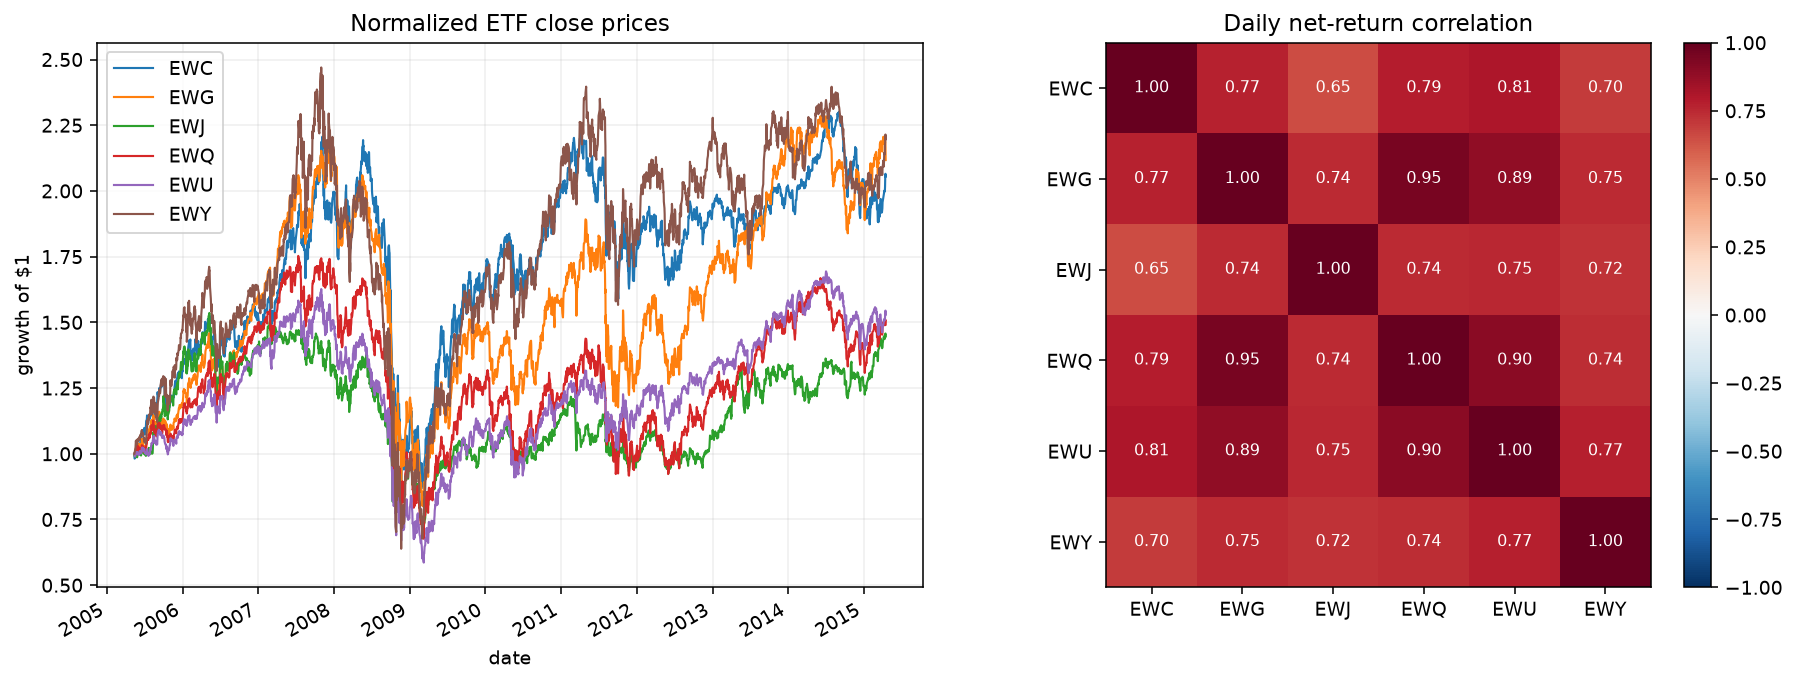

In [6]:
annualized_statistics = pd.DataFrame(
    {
        "annualized_mean_net_return": returns.mean() * 252,
        "annualized_volatility": returns.std(ddof=1) * np.sqrt(252),
        "minimum_daily_return": returns.min(),
        "maximum_daily_return": returns.max(),
    }
)
display(annualized_statistics)
show_figure(create_data_diagnostics_figure(etf_data))

## 7. 수식에서 코드로

| 개념 | 수식·제약 | 구현 |
|---|---|---|
| 순수익률 | $R_t=P_t/P_{t-1}-1$ | `calculate_net_returns` |
| Box 1.1 변환 | $R=e^r-1$ | `simulate_net_vs_log_returns` |
| 연속시간 근사 | $\mu\approx m-s^2/2$ | 각 표본의 `net_mean_minus_half_variance` |
| 포트폴리오 수익 | $F^T M$ | `weights @ mean_returns` |
| 포트폴리오 분산 | $F^T C F$ | `weights @ covariance @ weights` |
| 제약 | $F^T1=1, F^TM=m_p, F\ge0$ | `_solve_long_only_qp`의 활성집합/KKT 풀이 |
| Tangency | $\arg\max(m_p/\sigma_p)$ | 21개 격자의 `argmax(sharpes)` |
| Box 1.3 | $F=C^{-1}M/(1^TC^{-1}M)$ | `calculate_normalized_kelly_weights` |
| 표본 민감도 | 전반/후반의 같은 최적화 | `calculate_portfolio_theory_diagnostics` |

책의 역사적 MATLAB `quadprog` 대신, 자산이 6개라는 점을 이용해 63개
비어 있지 않은 활성집합을 모두 조사한다. 이 선택은 경계 비중의 최적화기
허용오차 차이를 줄인다.

## 8. Box 1.1 — 순수익률 평균과 로그수익률 평균

로그수익률이 정규분포일 때

$$\mu \approx m-\frac{s^2}{2}$$

를 확인한다. `N`이 커질수록 각 하위 기간의 평균은 `1/N`, 표준편차는
`2/sqrt(N)`으로 작아진다. 책은 MATLAB `rng(1)`, Python은 명시적으로
NumPy PCG64 seed 1을 사용하므로 개별 표본값이 아니라 근사의 수렴 성질을
비교한다. 같은 seed에서 세 `N`은 같은 난수열의 prefix이므로 서로 독립 표본은
아니다. seed 1의 표본운을 숨기지 않기 위해 200개 seed 분포도 계산한다.

,sample_size,log_mean,log_std,net_mean,net_std,net_mean_minus_half_variance,absolute_approximation_error
0,100,-4.722424e-03,0.171169,0.009512,0.168756,-4.726928e-03,4.504076e-06
1,10000,-1.182580e-04,0.019971,0.000081,0.019974,-1.183341e-04,7.609878e-08
2,1000000,5.820037e-07,0.001997,0.000003,0.001997,5.819915e-07,1.215841e-11


,sample_size,seed_count,median_error,p05_error,p95_error,seed_one_error,seed_one_percentile
0,100,200,1.006148e-03,1.426079e-04,2.761704e-03,4.504076e-06,0.0
1,10000,200,1.140276e-07,2.004298e-08,2.244598e-07,7.609878e-08,27.5
2,1000000,200,1.148662e-11,2.185582e-12,2.241279e-11,1.215841e-11,54.0


,sample_size,log_mean,book_log_mean,net_mean_minus_half_variance,book_approximation,absolute_approximation_error,book_identity_error
0,100,-4.722424e-03,0.000299,-4.726928e-03,-0.000641,4.504076e-06,9.403940e-04
1,10000,-1.182580e-04,0.000023,-1.183341e-04,0.000023,7.609878e-08,1.569375e-07
2,1000000,5.820037e-07,0.000003,5.819915e-07,0.000003,1.215841e-11,1.842526e-11


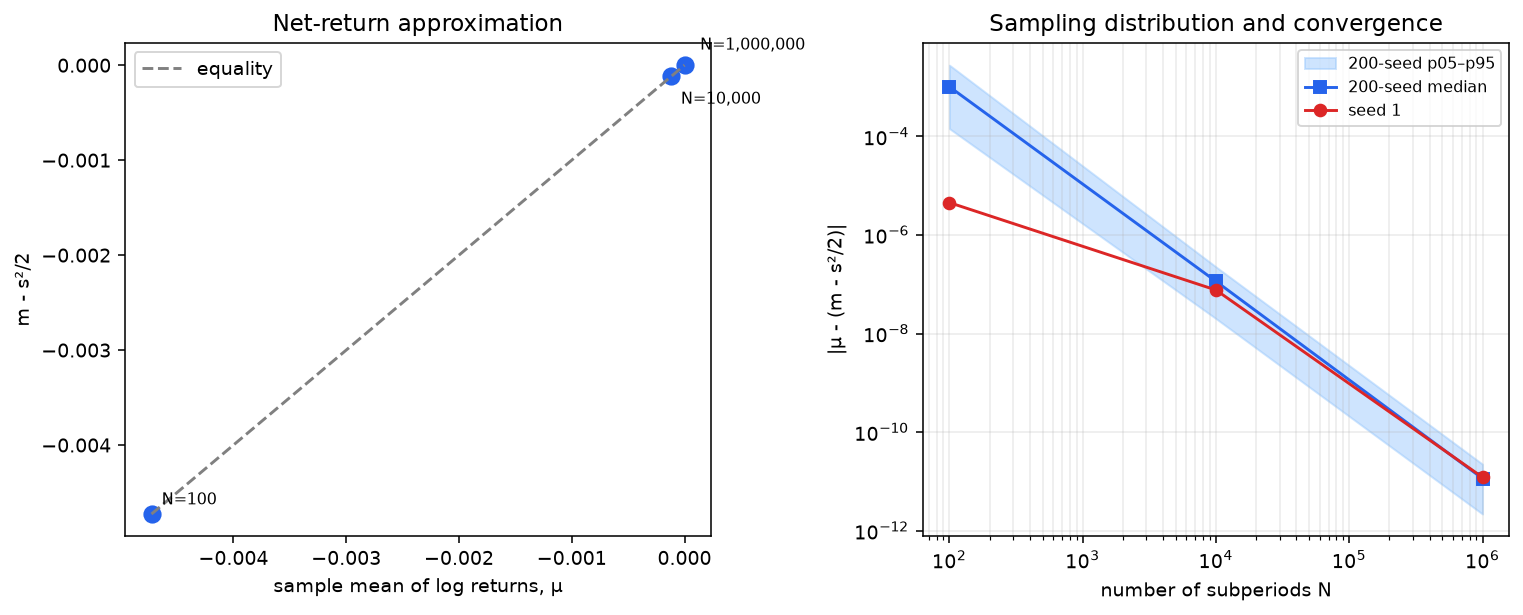

In [7]:
net_log = simulate_net_vs_log_returns()
seed_summary = summarize_net_log_seed_distribution()
net_log_table = pd.DataFrame([item.__dict__ for item in net_log])
seed_summary_table = pd.DataFrame([item.__dict__ for item in seed_summary])

book_rows = []
for sample_size, book in BOOK_NET_LOG_RESULTS.items():
    book_rows.append(
        {
            "sample_size": sample_size,
            "book_log_mean": book["log_mean"],
            "book_approximation": book["approximation"],
            "book_identity_error": abs(book["log_mean"] - book["approximation"]),
        }
    )
comparison = net_log_table.merge(pd.DataFrame(book_rows), on="sample_size")
display(net_log_table)
display(seed_summary_table)
display(
    comparison[
        [
            "sample_size",
            "log_mean",
            "book_log_mean",
            "net_mean_minus_half_variance",
            "book_approximation",
            "absolute_approximation_error",
            "book_identity_error",
        ]
    ]
)
show_figure(create_net_log_figure(net_log, seed_summary))

### Box 1.1 해석

위 표의 `seed_one_percentile`이 seed 1의 대표성을 직접 보여준다. 특히 작은
`N`에서 seed 1은 200개 중 극단적으로 오차가 작은 표본이므로, 그 한 점을
Python 구현의 우월성처럼 읽으면 안 된다. 책과 Python의 `μ` 값 차이는 난수
생성기 차이다. 판단 근거는 200시드 중앙값과 p05–p95 밴드가 `N` 증가에 따라
함께 감소하는지 여부다.

## 9. Box 1.2 — 롱온리 효율적 투자선

각 목표 일수익률 $m_p$에서 다음 문제를 푼다.

$$\min_F F^TCF \quad \text{s.t.}\quad F^TM=m_p,\;F^T1=1,\;F\ge0$$

21개 목표의 해 중 `m_p / 표준편차`가 최대인 점을 tangency, 분산이 최소인
점을 최소분산 포트폴리오로 표시한다. 무위험수익률은 책과 같이 0으로 둔다.

,daily_return,daily_volatility,daily_sharpe_rf0
tangency,0.000467,0.016525,0.028277
minimum_variance,0.000314,0.013679,0.022982


,python_tangency,book_tangency,python_minimum_variance,book_minimum_variance,abs_diff_tangency,abs_diff_minimum
EWC,0.451382,0.451338,0.385948,0.381518,0.000044,0.004430
EWG,0.263470,0.263445,0.000000,0.000033,0.000026,0.000033
EWJ,0.000000,0.000019,0.614052,0.604011,0.000019,0.010041
EWQ,0.000000,0.000005,0.000000,0.000134,0.000005,0.000134
EWU,0.000000,0.000007,0.000000,0.014300,0.000007,0.014300
EWY,0.285147,0.285186,0.000000,0.000004,0.000038,0.000004


,comparison
max_abs_tangency_weight_diff,4.437630e-05
python_minimum_variance,1.871269e-04
book_weights_variance_same_data,1.871667e-04
true_global_minimum_variance,1.871193e-04
grid_minus_global_variance,7.633920e-09


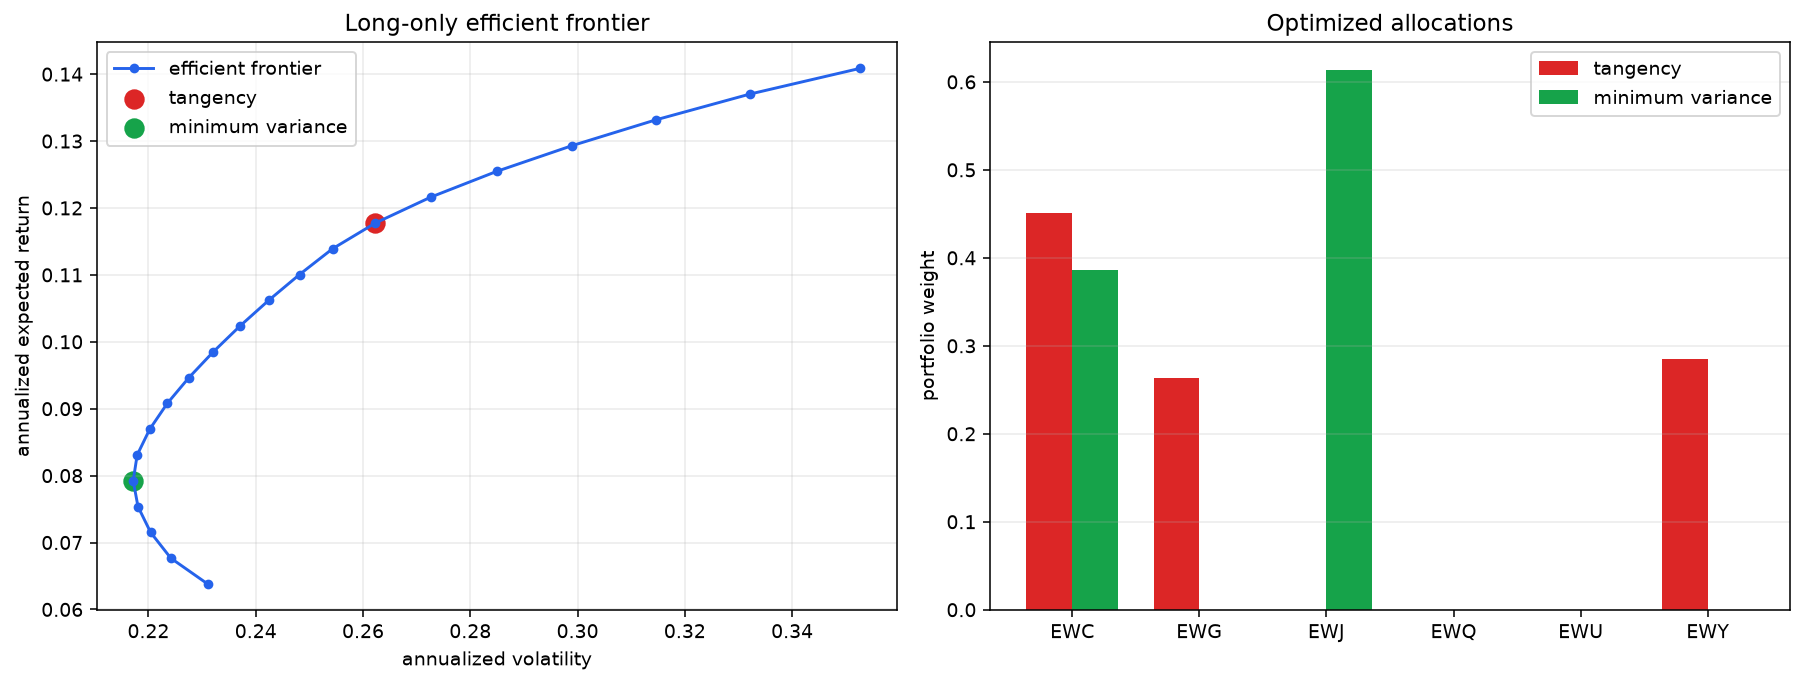

In [8]:
frontier = calculate_efficient_frontier(etf_data)
tangency = frontier.tangency_index
minimum = frontier.minimum_variance_index

frontier_summary = pd.DataFrame(
    {
        "daily_return": [frontier.targets[tangency], frontier.targets[minimum]],
        "daily_volatility": [
            frontier.standard_deviations[tangency],
            frontier.standard_deviations[minimum],
        ],
        "daily_sharpe_rf0": [frontier.sharpes[tangency], frontier.sharpes[minimum]],
    },
    index=["tangency", "minimum_variance"],
)
display(frontier_summary)

weight_comparison = pd.DataFrame(
    {
        "python_tangency": frontier.tangency_weights,
        "book_tangency": BOOK_TANGENCY_WEIGHTS,
        "python_minimum_variance": frontier.minimum_variance_weights,
        "book_minimum_variance": BOOK_MINIMUM_VARIANCE_WEIGHTS,
    },
    index=frontier.symbols,
)
weight_comparison["abs_diff_tangency"] = abs(
    weight_comparison["python_tangency"] - weight_comparison["book_tangency"]
)
weight_comparison["abs_diff_minimum"] = abs(
    weight_comparison["python_minimum_variance"]
    - weight_comparison["book_minimum_variance"]
)
display(weight_comparison)

book_min_variance = float(
    BOOK_MINIMUM_VARIANCE_WEIGHTS
    @ frontier.covariance
    @ BOOK_MINIMUM_VARIANCE_WEIGHTS
)
global_min_weights, global_min_variance = solve_global_long_only_minimum_variance(
    frontier.covariance
)
display(
    pd.Series(
        {
            "max_abs_tangency_weight_diff": weight_comparison["abs_diff_tangency"].max(),
            "python_minimum_variance": frontier.variances[minimum],
            "book_weights_variance_same_data": book_min_variance,
            "true_global_minimum_variance": global_min_variance,
            "grid_minus_global_variance": (
                frontier.variances[minimum] - global_min_variance
            ),
        },
        name="comparison",
    ).to_frame()
)
show_figure(create_efficient_frontier_figure(frontier))

### Box 1.2 해석

위 비교표의 최대 절대 차이가 허용오차 안이면 tangency 비중은 수치상
재현된다. 최소분산 비중은 더 다르지만 Python 해의 목적함수(분산)가 책의
출력 비중보다 낮다. 역사적 `quadprog`가 0 근처 자산에 작은 비중을 남긴
허용오차 차이이며, Python의 활성집합 해는 같은 목표수익률·완전 투자·롱온리
제약을 모두 만족한다. 21개 목표 격자의 최소와 목표 제약이 없는 진짜 global
minimum도 위 표에서 구분한다.

투자 관점에서 더 중요한 점은 평균수익률 추정이 불안정하다는 것이다.
Tangency 포트폴리오는 평균의 작은 변화에도 크게 움직일 수 있지만,
최소분산 포트폴리오는 상대적으로 추정이 쉬운 공분산에 더 의존한다.

## 10. Box 1.3 — Sharpe/Kelly 해와 추정 위험

공매도 제약이 없고 무위험수익률을 0으로 두면 Kelly 성장 최적화와 Sharpe
최대화 해는 $C^{-1}M$에 비례한다. 순비중을 1로 정규화하면

$$F_{analytic}=\frac{C^{-1}M}{1^TC^{-1}M}.$$

Box 1.2는 $F\ge0$을 강제하지만 Box 1.3의 분석해는 음수 비중과 큰 gross
exposure를 허용한다. 또 전체 기간의 앞·뒤 절반에서 각각 같은 롱온리 문제를
풀어 평균수익률 추정에 대한 민감도를 진단한다. 이 두 절반은 각각 자기 표본을
최적화하므로 표본 외 백테스트가 아니다.

,long_only_full,normalized_C_inv_M,long_only_first_half,long_only_second_half
EWC,0.451382,1.225891,0.721119,0.000000
EWG,0.263470,2.947697,0.000000,0.345084
EWJ,0.000000,-0.199561,0.000000,0.349289
EWQ,0.000000,-2.534770,0.000000,0.000000
EWU,0.000000,-0.976882,0.000000,0.305627
EWY,0.285147,0.537626,0.278881,0.000000


,diagnostic
long_only_daily_sharpe_rf0,0.028277
unconstrained_daily_sharpe_rf0,0.03846
unconstrained_gross_exposure,8.422428
split_date,2010-04-30
first_half_daily_sharpe_rf0,0.036041
second_half_daily_sharpe_rf0,0.030803
first_vs_second_weight_L1,2.0


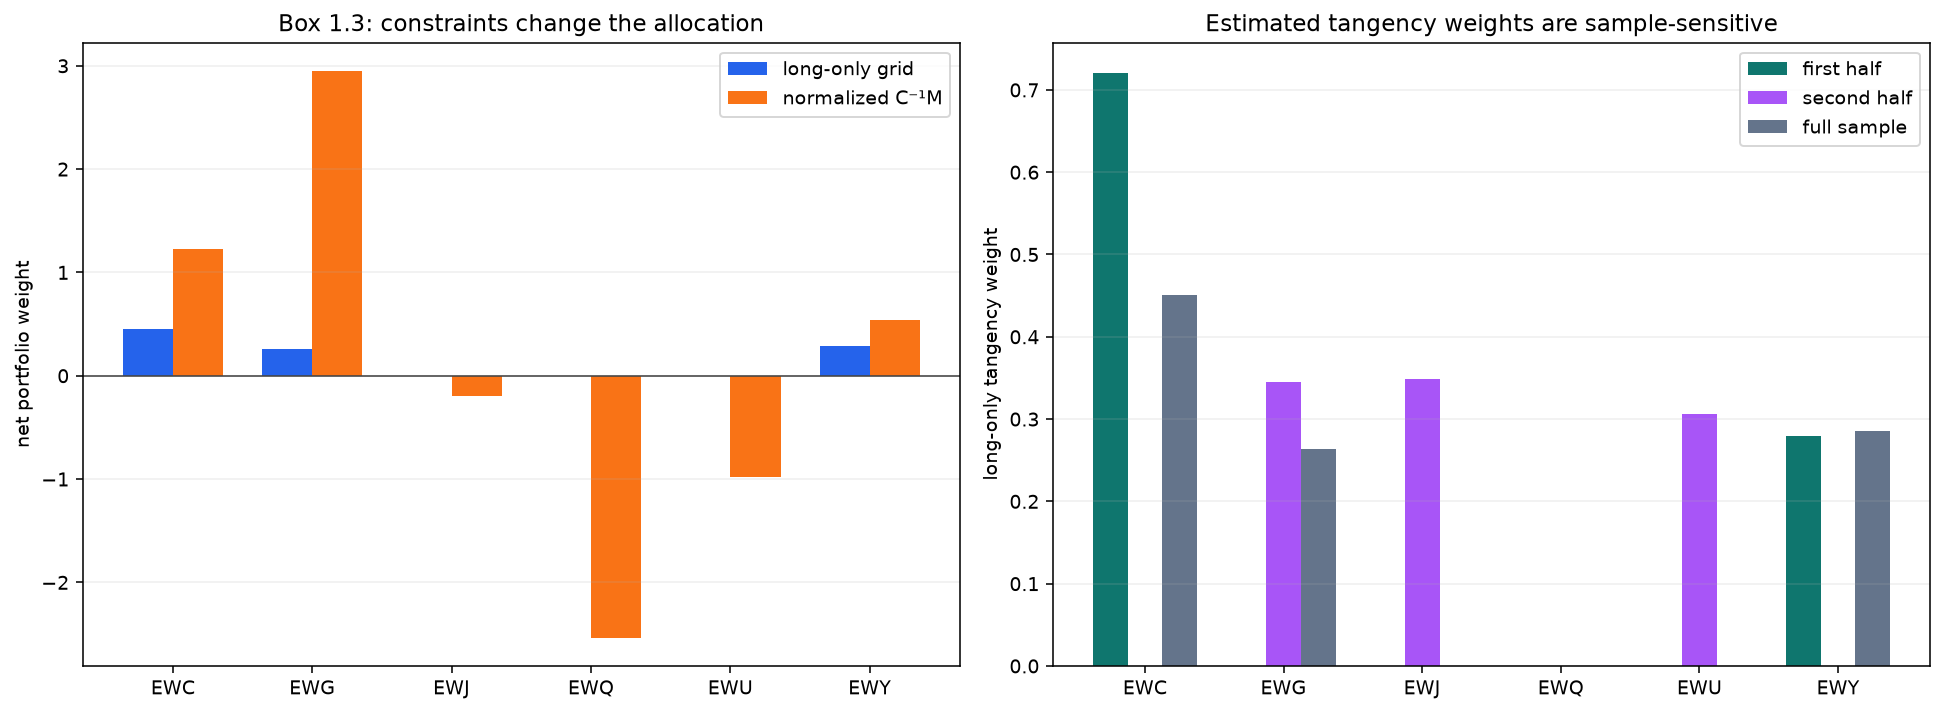

In [9]:
theory = calculate_portfolio_theory_diagnostics(etf_data, frontier)
box13_weights = pd.DataFrame(
    {
        "long_only_full": frontier.tangency_weights,
        "normalized_C_inv_M": theory.unconstrained_weights,
        "long_only_first_half": theory.first_half_weights,
        "long_only_second_half": theory.second_half_weights,
    },
    index=frontier.symbols,
)
display(box13_weights)
display(
    pd.Series(
        {
            "long_only_daily_sharpe_rf0": frontier.sharpes[tangency],
            "unconstrained_daily_sharpe_rf0": theory.unconstrained_daily_sharpe,
            "unconstrained_gross_exposure": theory.unconstrained_gross_exposure,
            "split_date": theory.split_date.date(),
            "first_half_daily_sharpe_rf0": theory.first_half_daily_sharpe,
            "second_half_daily_sharpe_rf0": theory.second_half_daily_sharpe,
            "first_vs_second_weight_L1": theory.split_weight_l1_distance,
        },
        name="diagnostic",
    ).to_frame()
)
show_figure(create_portfolio_theory_figure(frontier.symbols, frontier, theory))

### Box 1.3 해석과 risk parity

분석해는 허용된 공매도와 레버리지로 표본 Sharpe를 높이지만 net exposure 1에
비해 gross exposure가 매우 크다. 전반과 후반의 롱온리 tangency 비중도 거의
겹치지 않는다. 이는 기대수익률 점추정치가 조금만 바뀌어도 최적해가 급변한다는
책의 경고를 수치로 확인한 것이다.

최소분산은 불안정한 평균 추정에 덜 의존한다. Risk parity는 또 다른 대안이지만
단순 역변동성 비중은 자산 간 상관관계와 tail risk를 직접 통제하지 않는다.
책은 등레버리지·risk parity에서 위기 손실과 청산이 다른 구성요소로 전염될
수 있다고 경고하고, 그 대안으로 각 구성요소의 MDD를 같은 목표로 두는 방식을
제시한다. 이 노트북의 추가 경고는 MDD 타깃도 추정오차와 상관 급변에서 자유롭지
않다는 점이다. 2015년 All Weather의 약 7% 손실은 risk parity의 tail-risk
한계를 보여주는 역사적 예시다. 어떤 방식이든 표본 외 안정성, turnover,
차입·거래비용을 별도로 검증해야 한다.

## 11. 이 결과를 실전 성과로 해석하면 안 되는 이유

- **Look-ahead:** 전체 2005–2015 표본으로 평균·공분산과 비중을 동시에
  구했다. 미래 성과가 아니다.
- **선택·생존 편향:** 책이 정한 ETF 집합을 사후에 사용하고 EWZ·FXI를
  제외한다.
- **가격 메타데이터:** 공식 파일의 가격 조정 여부를 별도 공급자 데이터로
  독립 검증하지 않았다.
- **비용 누락:** 수수료, bid-ask spread, 슬리피지, 세금, 리밸런싱 회전율을
  계산하지 않았다.
- **모형 가정:** 무위험수익률 0, 과거 평균·공분산이 대표적이라는 가정을 쓴다.
- **표본외 검증 없음:** 실전 확장 시 롤링 창으로 추정하고 다음 기간에만
  비중을 적용한 뒤 비용을 차감해야 한다.

## 12. 실행 검증

마지막으로 데이터 해시, 결측·양수 조건, Box 1.1 수렴, 모든 효율적 투자선
비중·목표수익률 제약, 책의 tangency 허용오차, 최소분산 목적함수를 한 번에
검사한다.

In [10]:
checks = verify_results(etf_data, seed_summary, frontier, theory)
verification = pd.DataFrame(
    {
        "passed": checks,
        "class": {name: VERIFICATION_CLASSES[name] for name in checks},
    }
)
display(verification)
assert verification["passed"].all()
summary = verification_summary(checks)
display(pd.Series(summary).drop("classification").to_frame("count"))
print(
    f"{summary['total']}개 통과: 독립/경험 검증 "
    f"{summary['independent_or_empirical']}개, 계약 invariant "
    f"{summary['contract_invariant']}개"
)

,passed,class
official_data_checksum_matches,True,independent_or_empirical
data_has_no_missing_values,True,independent_or_empirical
data_prices_are_positive,True,independent_or_empirical
net_log_error_decreases,True,independent_or_empirical
net_log_final_error_below_1e_9,True,independent_or_empirical
frontier_weights_nonnegative,True,contract_invariant
frontier_weights_sum_to_one,True,contract_invariant
frontier_meets_target_returns,True,contract_invariant
tangency_weights_match_book,True,independent_or_empirical
minimum_variance_no_worse_than_book,True,independent_or_empirical


,count
total,15
passed,15
independent_or_empirical,8
contract_invariant,7


15개 통과: 독립/경험 검증 8개, 계약 invariant 7개


## 결론

1장의 운영 원칙은 시장 데이터부터 주문·체결 상태까지 동일한 전략 코어와
검증 가능한 데이터 계보를 유지하는 것이다. 성과는 Sharpe 하나가 아니라 MDD,
duration, 비용과 운영 리스크를 함께 봐야 한다.

수치적으로 Box 1.1의 연속시간 근사, Box 1.2의 책 tangency 비중, Box 1.3의
`C⁻¹M` 일차조건을 재현했다. 동시에 분석해의 큰 gross exposure와 전·후반의
서로 다른 tangency 비중은 표본 내 최고 Sharpe가 실전 최적해라는 믿음을
반박한다.

따라서 이 노트북은 장 전체의 개념과 공식 예제를 연결한 **수학·수치 검증**이지
거래 전략의 수익성 증거가 아니다. 진짜 백테스트에는 시점별 추정, 표본 외
적용, 리밸런싱 규칙, 거래비용과 체결 모델이 필요하다.